In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fig S6

This code use the following csv data created with the corresponging C++ code:
- Parameters sensitivity/kCS/ext_rate_kcs_high_antibiotic_inhibition.csv --- Parameters sensitivity/kCS/kcs_extinction_rate_high_antibiotic_inhibition.cpp --- FigS6

In [2]:
df = pd.read_csv('Parameters sensitivity/kCS/ext_rate_kcs_high_antibiotic_inhibition.csv')


dfext = df[df['FinalTime'] < 150].groupby(['SeasonLength','CS']).count().reset_index()
dfext['ExtRate'] = dfext['Trajectory'] / 10000
dfext

,SeasonLength,CS,Trajectory,FinalTime,ExtRate
0,10.0,0.001,8846,8846,0.8846
1,10.0,0.112,8799,8799,0.8799
2,10.0,0.223,8831,8831,0.8831
3,10.0,0.334,8786,8786,0.8786
4,10.0,0.445,8822,8822,0.8822
5,10.0,0.556,8763,8763,0.8763
6,10.0,0.667,8723,8723,0.8723
7,10.0,0.778,8691,8691,0.8691
8,10.0,0.889,8701,8701,0.8701
9,10.0,1.000,8580,8580,0.8580


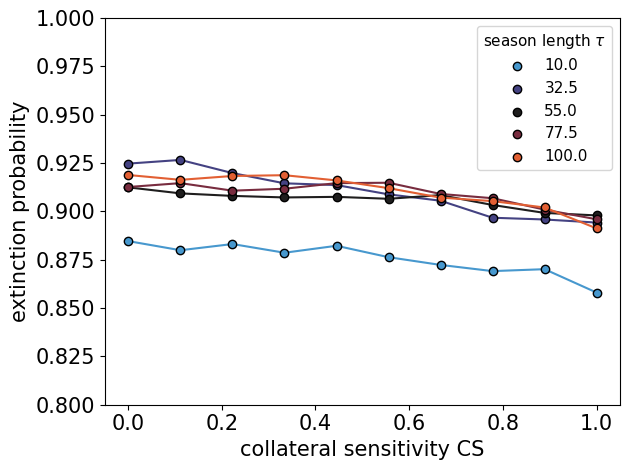

In [4]:
orden = sorted(dfext['SeasonLength'].unique(), reverse=True)

colors = sns.color_palette('icefire_r',len(orden))
special_palette=dict(zip(orden,colors))

for u,dfu in dfext.groupby('SeasonLength'):
    plt.plot(dfu['CS'], dfu['ExtRate'],color=special_palette[u])
    plt.scatter(dfu['CS'], dfu['ExtRate'],ec='black',zorder=2,label=u,color=special_palette[u])
    
plt.legend(title='season length '+r'$\tau$',fontsize=11,title_fontsize=11,loc='upper right')
plt.xlabel('collateral sensitivity CS', fontsize=15)
plt.ylabel('extinction probability', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(0.8,1)
plt.tight_layout()
plt.savefig('FigS6.png',dpi=300)
plt.show()

Collateral sensitivity is irrelevant when high dosis of antibiotic are applied.